In [18]:
# 1. Importacion de librerias necesarias

from pathlib import Path

import cv2
import matplotlib.pyplot as plt

# Los archivos estan junto a este notebook.
base_dir = Path.cwd()
impath = base_dir / "descargar (1).webp"

image = cv2.imread(str(impath))
if image is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {impath}")

print("version:", cv2.__version__)
print("imagen:", image.shape)
print("cascadeClassifier:", hasattr(cv2, "CascadeClassifier"))

version: 4.14.0
imagen: (180, 132, 3)
cascadeClassifier: True


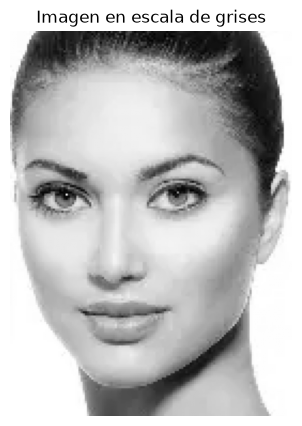

In [19]:
gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 5))
plt.imshow(gray_img, cmap="gray")
plt.title("Imagen en escala de grises")
plt.axis("off")
plt.show()

In [20]:
# 2. Cargar el clasificador Haar Cascade para deteccion de rostros
cascade_path = "haarcascade_frontalface_default.xml"
if not os.path.exists(cascade_path):
    cascade_path = os.path.join("Modelos_ML", "VisionArtificial", "haarcascade_frontalface_default.xml")

face_cascade = cv2.CascadeClassifier(cascade_path)

# Respaldo: Si no lo encuentra localmente, usar el modelo incluido en OpenCV
if face_cascade.empty():
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

if face_cascade.empty():
    raise IOError("Error: No se pudo cargar el clasificador Haar Cascade.")
else:
    print("Clasificador de rostros cargado exitosamente.")

Clasificador de rostros cargado exitosamente.


In [21]:
# 3. Funcion para detectar rostros en una imagen estatica
def detectar_rostros_imagen(ruta_imagen, scale_factor=1.03, min_neighbors=3, min_size=(30, 30)):
    # Comprobar existencia de la ruta
    if not os.path.exists(ruta_imagen):
        ruta_alternativa = os.path.join("Modelos_ML", "VisionArtificial", ruta_imagen)
        if os.path.exists(ruta_alternativa):
            ruta_imagen = ruta_alternativa
        else:
            print(f"Error: No se encontro la imagen en '{ruta_imagen}'.")
            return None, None

    # Cargar imagen en BGR
    img = cv2.imread(ruta_imagen)
    if img is None:
        print(f"Error: No se pudo leer la imagen '{ruta_imagen}'.")
        return None, None

    # Convertir a escala de grises para el clasificador
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Escanear y detectar rostros
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size
    )

    print(f"Total de rostros detectados: {len(faces)}")

    # Crear copia para dibujar y no modificar la original
    img_result = img.copy()

    # Dibujar rectangulos y etiquetas sobre cada cara detectada
    for i, (x, y, w, h) in enumerate(faces, start=1):
        # Rectangulo verde
        cv2.rectangle(img_result, (x, y), (x + w, y + h), (0, 255, 0), 2)
        # Etiqueta con numero de cara
        cv2.putText(img_result, f"Rostro #{i}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Convertir a RGB para mostrar con Matplotlib
    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen en el notebook
    plt.figure(figsize=(10, 7))
    plt.imshow(img_rgb)
    plt.title(f"Deteccion de Rostros - Encontrados: {len(faces)}")
    plt.axis('off')
    plt.show()

    return img_result, faces

Total de rostros detectados: 1


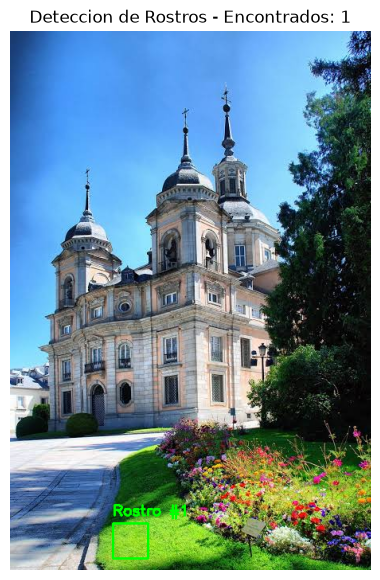

In [22]:
# 4. Escanear la imagen 'images.jpg'
imagen_resultado, rostros = detectar_rostros_imagen("images.jpg")

In [23]:
# 5. Funcion para procesar fotogramas de la camara web en tiempo real
def detect_bounding_box(vid):
    gray_frame = cv2.cvtColor(vid, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray_frame, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
    )
    for (x, y, w, h) in faces:
        cv2.rectangle(vid, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return faces

In [10]:
# 6. Acceder a la camara de nuestro pc y procesar video en tiempo real
video_captado = cv2.VideoCapture(0)

while True:
    result, video_frame = video_captado.read()
    if result is False:
        print("No se pudo acceder a la camara o finalizo el flujo.")
        break
        
    faces = detect_bounding_box(video_frame)

    cv2.imshow("Mi cara detectada - Presiona 'q' para salir", video_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

# Liberar camara y cerrar ventanas FUERA del bucle while
video_captado.release()
cv2.destroyAllWindows()